# S04 · From Atom-Mapped Reactions to DPO Rules: ITS, Reaction Centers, and Fast Clustering

<div class="alert alert-block alert-info">
<b>Welcome to SynEdu.</b><br>
This talktorial is part of <b>SynEdu</b>, a lightweight, research-oriented teaching series built around the
<b>Syn</b> ecosystem and <b>RDKit</b> for practical, reproducible reaction modeling.
</div>

<div class="alert alert-block alert-success">
<b>What you will gain.</b><br>
You will learn a complete, <b>mapping → ITS → reaction center → clustering → rule</b> pipeline:
starting from <b>1000 pre-mapped reactions (from a local JSON/JSON.GZ dataset)</b>, we assume atom maps are already present (generated e.g. with RXNMapper upstream), construct an
<b>ITS (Imaginary Transition State)</b> graph, extract a <b>reaction center</b>, cluster centers by
<b>typed isomorphism</b>, accelerate clustering with a <b>Weisfeiler–Lehman (WL) hash prefilter</b>,
and finally convert each center into a <b>DPO (double-pushout) graph transformation rule</b>.
</div>

<div class="alert alert-block alert-warning">
<b>Reproducibility note.</b><br>
Atom-mapping quality and rule extraction depend on tool versions, sanitization, charge handling,
and the precise definition of “reaction center” (bonds only vs bonds + atoms + radius context).
Always record package versions and settings, and persist intermediate artifacts:
mapped reaction SMILES, ITS graphs, centers, hashes, and extracted rules.
</div>

## Aim of this talktorial

Build a chemically interpretable and mathematically clean pipeline from *mapped reactions* to *graph rewriting rules*.

## Learning outcomes

After completing S04, you can:

1. Map a batch of reaction SMILES using <b>RXNMapper</b>.
2. Construct an <b>ITS graph</b> from a mapped reaction (atoms as nodes, (reactant,product) bond labels as edges).
3. Extract a <b>reaction center</b> and (optionally) a <b>radius-r context</b>.
4. Cluster reaction centers using <b>typed graph isomorphism</b>.
5. Speed up clustering via <b>WL hashing</b> as an isomorphism-invariant *prefilter*.
6. Convert a reaction center into a <b>DPO rule</b> \(L \leftarrow K \rightarrow R\) (delete/add bonds; keep context).

## Roadmap

- **0. Setup & data** (1000 mapped reactions from `./data/smart.json.gz`)
- **1. Theory** (mapped reactions, ITS, center, isomorphism, WL, DPO)
- **2. (Optional) Atom-mapping** (RXNMapper, if you start from unmapped reactions)
- **3. ITS construction**
- **4. Reaction center extraction**
- **5. Center clustering via isomorphism**
- **6. WL hash prefilter acceleration**
- **7. Convert centers to DPO rules + export**
- **8. Exercises & quiz**


## Authors and contributions

- Tieu-Long Phan (SynEdu / Syn ecosystem)
- (Add contributors here)

> If you reuse code snippets or figures from this notebook, please cite SynEdu appropriately and pin versions in your supplement.


## 0. Setup & data


In [1]:
# Core scientific stack
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import pandas as pd
import networkx as nx

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole  # noqa: F401

print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)
print("Pandas version:", pd.__version__)


RDKit version: 2025.09.3
NetworkX version: 3.6.1
Pandas version: 2.3.3


### 0.0 Note on atom mapping (RXNMapper)

In **S01/S04** we often start from *unmapped* reaction SMILES and run **RXNMapper** to obtain atom-map IDs.
In this S04 run, we **skip mapping** because our dataset file `./data/smart.json.gz` already contains **atom-mapped** reactions.

> If you ever start from unmapped reactions, you can still plug RXNMapper into the same pipeline:
> produce a column `mapped_rxn` and continue with ITS construction below.


### 0.1 Reaction data (1000 mapped reactions)

We load a local dataset from:

- `./data/smart.json.gz`

The file may be either:

- **plain JSON** (often misnamed as `.gz`), or
- **gzip-compressed JSON**.

Each entry is expected to contain a **mapped reaction string** (reaction SMILES/SMARTS) with atom-map IDs like `:12`.
In our dataset, the mapped reaction is stored under the key **`"smart"`** (and optionally an identifier like `"R-id"`).

We will load **1000 mapped reactions** and store them in a DataFrame `df_map` with at least:

- `mapped_rxn` — mapped reaction string (`reactants >> products`)
- `rxn_id` — optional id (if available)


In [2]:
import json
import gzip
from pathlib import Path
from typing import Any, Union

def load_json_auto(path: Union[str, Path]) -> Any:
    """
    Load JSON from .json or .json.gz.
    Auto-detects gzip by magic bytes, not filename.

    Works even if a file is misnamed *.json.gz but is plain JSON.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    with open(path, "rb") as f:
        magic = f.read(2)

    is_gzip = magic == b"\x1f\x8b"
    if is_gzip:
        with gzip.open(path, "rt", encoding="utf-8") as f:
            return json.load(f)
    else:
        with open(path, "rt", encoding="utf-8") as f:
            return json.load(f)

def _get_mapped_field(rec: dict) -> str:
    """
    Extract the mapped reaction string from a record.

    We try common keys in reaction datasets.
    """
    for k in ("mapped_rxn", "mapped_smiles", "rxn_smiles_mapped", "smart", "smarts", "reaction"):
        v = rec.get(k)
        if isinstance(v, str) and ">>" in v:
            return v
    raise KeyError(f"Could not find a mapped reaction field in keys={list(rec.keys())}")

raw = load_json_auto("./data/smart.json.gz")
# raw is typically a list[dict]; occasionally it can be a dict with a top-level list under a key.
if isinstance(raw, dict):
    # try common containers
    for k in ("data", "records", "reactions"):
        if k in raw and isinstance(raw[k], list):
            raw = raw[k]
            break

if not isinstance(raw, list):
    raise TypeError(f"Expected list of records, got: {type(raw)}")

N = 1000
raw = raw[:N]

rows = []
for rec in raw:
    if not isinstance(rec, dict):
        continue
    mapped = _get_mapped_field(rec)
    rxn_id = rec.get("R-id", rec.get("id", rec.get("rxn_id", None)))
    rows.append({"rxn_id": rxn_id, "mapped_rxn": mapped})

df_map = pd.DataFrame(rows)
display(df_map.head(10))
print("Total mapped reactions loaded:", len(df_map))
print("Missing mapped_rxn:", int(df_map["mapped_rxn"].isna().sum()))


,rxn_id,mapped_rxn
0,7873,[CH3:1][C:2]([CH3:3])([CH3:4])[O:5][C:6](=[O:7...
1,42468,[Br:1][CH2:2][c:3]1[cH:4][cH:6][c:7]([Br:8])[c...
2,24541,[CH3:1][N:2]([CH3:3])[CH2:4][CH2:5][NH:6][H:7]...
3,40699,[CH3:1][O:2][c:3]1[cH:4][cH:6][cH:7][cH:8][c:5...
4,34914,[CH3:1][CH:2]([CH3:3])[O:4][H:5].[O:6]=[C:7]([...
5,11951,[CH3:1][N:2]([NH2:3])[H:4].[O:5]=[N+:6]([O-:7]...
6,15509,[CH3:1][O:2][C:3](=[O:4])[c:5]1[cH:6][cH:8][cH...
7,49367,[CH3:1][C:2]([CH3:3])([CH3:4])[O:5][C:6](=[O:7...
8,28488,[H:1][H:2].[NH2:3][CH2:4][CH2:5][CH:6]=[CH:7][...
9,10715,[CH3:1][CH2:2][NH:3][H:4].[CH3:5][c:6]1[cH:7][...


Total mapped reactions loaded: 1000
Missing mapped_rxn: 0


## 1. Theory (formal, but chemist-friendly)

### 1.1 Atom-mapped reactions as typed structures

An unmapped reaction SMILES is a string

$$
\texttt{rxn} = \texttt{R} \;\gg\; \texttt{P},
$$

where $\texttt{R}$ (reactants and reagents) and $\texttt{P}$ (products) are dot-separated
lists of molecules.

An **atom-mapped reaction** augments each atom with an integer **map identifier**.
Conceptually, atom mapping defines a *partial correspondence* between atoms on the
reactant and product sides.

Let

$$
A_R \quad\text{and}\quad A_P
$$

be the sets of atoms on the reactant and product sides, respectively, and let

$$
M \subset \mathbb{N}
$$

be the set of map identifiers appearing in the reaction.
The atom-mapped reaction induces two functions

$$
\mu_R : A_R \to M,
\qquad
\mu_P : A_P \to M,
$$

where atoms sharing the same map identifier are interpreted as representing
“the same atom through the transformation”.

In practice, atom mapping may be imperfect:
missing map identifiers, duplicated identifiers, or unmapped leaving groups may occur.
All downstream constructions are therefore designed to be **robust**:
invalid or inconsistent cases are detected, warned about, and skipped.

---

### 1.2 ITS (Imaginary Transition State) graph

The **Imaginary Transition State (ITS)** represents the reaction as a single graph
by explicitly encoding bond changes between reactants and products.

Let $B$ be the set of allowed bond labels
(e.g. $\{1,2,3,1.5\}$ for single, double, triple, and aromatic bonds),
and introduce a special symbol $\bot$ denoting **bond absence**.

The ITS of an atom-mapped reaction is defined as a **typed graph**

$$
G_{\mathrm{ITS}} = (V, E, a, b_R, b_P),
$$

where:

- $V \subseteq M$ is the set of atom map identifiers used as node identifiers;
- $a : V \to \Sigma$ assigns atom types (e.g. element symbol, optionally charge);
- $E$ is the set of unordered edges between atom identifiers;
- $b_R : E \to B \cup \{\bot\}$ assigns the **reactant-side bond label**;
- $b_P : E \to B \cup \{\bot\}$ assigns the **product-side bond label**.

Chemical interpretation:

- $b_R(e) = \bot$ and $b_P(e) \neq \bot$ corresponds to **bond formation**;
- $b_R(e) \neq \bot$ and $b_P(e) = \bot$ corresponds to **bond breaking**;
- $b_R(e) \neq b_P(e)$ with both present corresponds to a **bond order or aromaticity change**.

Thus, the ITS compactly encodes the full local transformation in a single object.

---

### 1.3 Reaction center and radius-$r$ context

The **reaction center** is defined as the part of the ITS where changes occur.

First, define the set of changed edges

$$
\Delta E = \{\, e \in E \mid b_R(e) \neq b_P(e) \,\}.
$$

The **core atom set** is then

$$
C_0
=
\{\, v \in V \mid \exists e \in \Delta E \text{ incident to } v \,\},
$$

i.e. the atoms directly involved in bond changes.
Optionally, atoms with changed intrinsic states
(e.g. formal charge changes) may also be included in $C_0$.

To incorporate local chemical context, we define the **radius-$r$ expansion**

$$
C_r
=
\{\, u \in V \mid \mathrm{dist}_{G_{\mathrm{ITS}}}(u, C_0) \le r \,\},
$$

where $\mathrm{dist}_{G_{\mathrm{ITS}}}$ denotes the graph distance in the ITS.
The induced subgraph

$$
G_{\mathrm{ITS}}[C_r]
$$

is referred to as the **reaction-center graph with radius $r$**.

---

### 1.4 Clustering reaction centers by typed isomorphism

Two reaction-center graphs $G$ and $H$ are **typed isomorphic** if there exists a bijection

$$
\varphi : V(G) \to V(H)
$$

such that:

$$
a_G(v) = a_H(\varphi(v))
\quad\text{for all } v \in V(G),
$$

and

$$
\bigl(b_R, b_P\bigr)_G(\{u,v\})
=
\bigl(b_R, b_P\bigr)_H(\{\varphi(u), \varphi(v)\})
\quad\text{for all } \{u,v\} \in E(G).
$$

Chemically, this means that the two reactions share the **same local transformation
pattern**, independent of atom numbering or molecular size.

Reaction-center clustering groups reactions by this equivalence relation.

---

### 1.5 Weisfeiler--Lehman hash as a fast prefilter

Exact graph isomorphism testing becomes expensive for large collections of
reaction-center graphs.
To accelerate clustering, we use the **Weisfeiler--Lehman (WL) graph hash**.

The WL procedure iteratively refines node labels by hashing:

$$
\text{current node label}
\;+\;
\text{multiset of neighboring node and edge labels}.
$$

The final WL hash is an **isomorphism invariant**:
isomorphic graphs always share the same hash.
However, the invariant is **not complete**:
non-isomorphic graphs may occasionally collide.

Therefore, WL hashing is used only as a **prefilter**:

1. group reaction-center graphs by identical WL hash;
2. perform exact typed isomorphism checks only within each hash bucket.

This strategy preserves correctness while dramatically reducing runtime.

---

### 1.6 From reaction centers to DPO rules

A **double-pushout (DPO) rule** in graph rewriting is defined as a span

$$
p
=
\left(
L \xleftarrow{\;\ell\;} K \xrightarrow{\;r\;} R
\right),
$$

where:

- $L$ is the **left-hand side** pattern to be matched;
- $R$ is the **right-hand side** pattern produced by the rewrite;
- $K$ is the **context graph** that is preserved.

In the setting of atom-mapped chemical reactions:

- nodes of $K$ correspond to atoms preserved through the reaction;
- edges of $K$ correspond to bonds whose type does not change;
- edges present in $L$ but not in $R$ are **deleted bonds**;
- edges present in $R$ but not in $L$ are **created bonds**.

Atom-state changes (e.g. formal charge) are naturally represented as
node attributes that may differ between $L$ and $R$,
while $K$ retains only invariant identity information
(e.g. element symbol).

In practice, we extract rules as follows:

- $L$: reactant-side bonds induced on $C_r$;
- $R$: product-side bonds induced on $C_r$;
- $K$: intersection of bonds on $C_r$ whose labels are unchanged.

This construction makes the common intuition of
“reaction centers as rewriting rules”
explicit in precise graph-theoretic terms.


## 2. Atom mapping (already provided)

The downstream ITS / reaction-center pipeline assumes each atom has a **map id** that is consistent
between reactant and product sides.

In this notebook we **do not run RXNMapper**.
Instead, we **validate** that the loaded reactions look mapped:
- the reaction string contains `:n` map annotations,
- RDKit parses the molecules,
- at least one mapped atom appears on each side.


In [3]:
from collections import Counter
from rdkit import Chem

def count_mapped_atoms(smiles: str) -> tuple[int, int]:
    r, p = smiles.split(">>")
    r_mols = [Chem.MolFromSmiles(s) for s in r.split(".") if s]
    p_mols = [Chem.MolFromSmiles(s) for s in p.split(".") if s]
    if any(m is None for m in r_mols + p_mols):
        return 0, 0

    r_maps = [a.GetAtomMapNum() for m in r_mols for a in m.GetAtoms() if a.GetAtomMapNum()]
    p_maps = [a.GetAtomMapNum() for m in p_mols for a in m.GetAtoms() if a.GetAtomMapNum()]
    return len(r_maps), len(p_maps)

stats = Counter()
bad_examples = []

for s in df_map["mapped_rxn"].dropna().tolist():
    if ">>" not in s:
        stats["no_reaction_arrow"] += 1
        bad_examples.append(s)
        continue
    rm, pm = count_mapped_atoms(s)
    if rm == 0 or pm == 0:
        stats["no_mapped_atoms"] += 1
        bad_examples.append(s)
    else:
        stats["ok"] += 1

print("Validation stats:", dict(stats))
if bad_examples:
    print("\nFirst problematic example:")
    print(bad_examples[0][:300], "...")
else:
    print("All checked reactions appear to be atom-mapped and RDKit-parseable.")


Validation stats: {'ok': 1000}
All checked reactions appear to be atom-mapped and RDKit-parseable.


### 2.1 Inspect a mapped reaction

Our dataset stores a reaction SMILES where atoms carry map ids like `:12`.  
We will parse these map ids and build our ITS.


[CH3:1][C:2]([CH3:3])([CH3:4])[O:5][C:6](=[O:7])[N:8]1[CH2:9][CH2:11][N:12]([H:13])[CH2:14][CH2:10]1.[O:15]=[S:16](=[O:17])([c:18]1[cH:20][cH:22][cH:23][cH:24][cH:21]1)[N:19]1[CH2:25][CH2:27][O:28][c:29]2[c:26]1[cH:35][c:33]([Cl:34])[cH:32][c:30]2[Br:31]>>[CH3:1][C:2]([CH3:3])([CH3:4])[O:5][C:6](=[O:7])[N:8]1[CH2:9][CH2:11][N:12]([c:30]2[c:29]3[c:26]([cH:35][c:33]([Cl:34])[cH:32]2)[N:19]([S:16](=[O:15])(=[O:17])[c:18]2[cH:20][cH:22][cH:23][cH:24][cH:21]2)[CH2:25][CH2:27][O:28]3)[CH2:14][CH2:10]1.[H:13][Br:31]
Reactant side (mapped)


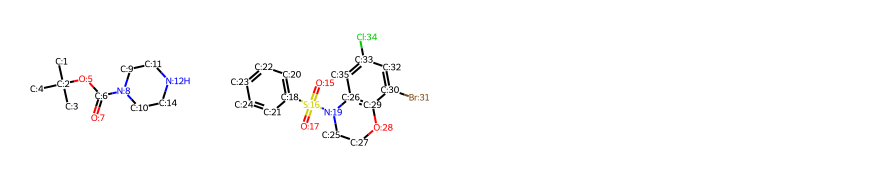

Product side (mapped)


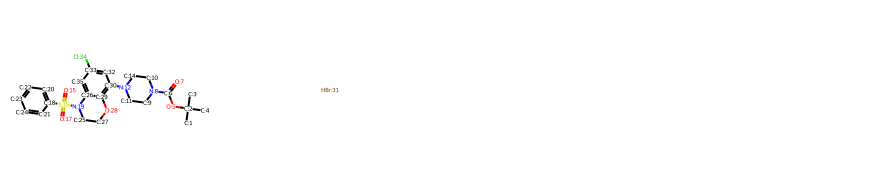

In [4]:
from rdkit.Chem import Draw
from IPython.display import display

def _split_rxn_smiles(rxn_smiles: str) -> Tuple[str, str]:
    if ">>" not in rxn_smiles:
        raise ValueError(f"Not a reaction SMILES: {rxn_smiles}")
    r, p = rxn_smiles.split(">>")
    return r, p

def draw_reaction_sides(mapped_rxn: str, max_mols_per_side: int = 4):
    r, p = _split_rxn_smiles(mapped_rxn)
    r_mols = [Chem.MolFromSmiles(s) for s in r.split(".") if s]
    p_mols = [Chem.MolFromSmiles(s) for s in p.split(".") if s]

    # show atom map numbers in the depiction
    for m in (r_mols + p_mols):
        if m is None:
            continue
        for a in m.GetAtoms():
            amap = a.GetAtomMapNum()
            if amap:
                a.SetProp("molAtomMapNumber", str(amap))

    img_r = Draw.MolsToGridImage([m for m in r_mols if m is not None][:max_mols_per_side], molsPerRow=4, subImgSize=(220, 180))
    img_p = Draw.MolsToGridImage([m for m in p_mols if m is not None][:max_mols_per_side], molsPerRow=4, subImgSize=(220, 180))

    print("Reactant side (mapped)")
    display(img_r)
    print("Product side (mapped)")
    display(img_p)

# Pick a reaction that is mapped
_example = df_map.loc[df_map["mapped_rxn"].notna(), "mapped_rxn"].iloc[0] if df_map["mapped_rxn"].notna().any() else None
if _example:
    print(_example)
    draw_reaction_sides(_example)
else:
    print("No mapped reaction available in df_map (run mapping cell above).")    


## 3. Construct the ITS graph


### 3.1 Implementation idea (from mapped SMILES → ITS)

We parse the mapped reaction into RDKit molecules on each side.

For each atom (with map id \(m\)) we record (at least):

- element symbol
- formal charge on reactant side and product side

For each bond between map ids \((u,v)\) we record:

- \(b_R(u,v)\): reactant bond order (or \(\bot\))
- \(b_P(u,v)\): product bond order (or \(\bot\))

We then take the **union** of reactant and product bonds as edges of the ITS.

> Chemistry convention used here:
> aromatic bonds are treated as order \(1.5\).


In [5]:
from collections import defaultdict

BondOrder = Optional[float]

def bond_order(b: Chem.Bond) -> float:
    """Convert an RDKit bond into a numeric order (with aromatic=1.5)."""
    bt = b.GetBondType()
    if bt == Chem.rdchem.BondType.SINGLE:
        return 1.0
    if bt == Chem.rdchem.BondType.DOUBLE:
        return 2.0
    if bt == Chem.rdchem.BondType.TRIPLE:
        return 3.0
    if bt == Chem.rdchem.BondType.AROMATIC:
        return 1.5
    # fall back for unusual bond types
    return float(b.GetBondTypeAsDouble())

def atoms_by_map_id(mols: Sequence[Chem.Mol]) -> Dict[int, Chem.Atom]:
    """Return a map_id -> atom object dict for a side of the reaction.

    If the same map id appears multiple times, we keep the first occurrence.
    """
    out: Dict[int, Chem.Atom] = {}
    for m in mols:
        if m is None:
            continue
        for a in m.GetAtoms():
            amap = int(a.GetAtomMapNum() or 0)
            if amap <= 0:
                continue
            out.setdefault(amap, a)
    return out

def bonds_by_map_pair(mols: Sequence[Chem.Mol]) -> Dict[Tuple[int, int], float]:
    """Return (min(map_i,map_j), max(...)) -> bond_order for all bonds on one side."""
    out: Dict[Tuple[int, int], float] = {}
    for m in mols:
        if m is None:
            continue
        for b in m.GetBonds():
            ai = int(b.GetBeginAtom().GetAtomMapNum() or 0)
            aj = int(b.GetEndAtom().GetAtomMapNum() or 0)
            if ai <= 0 or aj <= 0:
                continue
            key = (ai, aj) if ai < aj else (aj, ai)
            out[key] = bond_order(b)
    return out

def mapped_rxn_to_its(mapped_rxn: str) -> nx.Graph:
    """Build an ITS graph from a mapped reaction SMILES.

    Nodes: map ids (ints)
    Node attrs:
      - symbol
      - r_charge, p_charge
    Edges: union of reactant/product bonds (undirected)
    Edge attrs:
      - r_order (float or None)
      - p_order (float or None)
      - changed (bool)
    """
    r_smi, p_smi = _split_rxn_smiles(mapped_rxn)
    r_mols = [Chem.MolFromSmiles(s) for s in r_smi.split(".") if s]
    p_mols = [Chem.MolFromSmiles(s) for s in p_smi.split(".") if s]

    r_atoms = atoms_by_map_id(r_mols)
    p_atoms = atoms_by_map_id(p_mols)

    V = set(r_atoms) | set(p_atoms)
    if not V:
        raise ValueError("No mapped atoms found (map ids missing?).")

    G = nx.Graph()
    # nodes
    for mid in sorted(V):
        a_r = r_atoms.get(mid)
        a_p = p_atoms.get(mid)

        symbol = None
        if a_r is not None:
            symbol = a_r.GetSymbol()
        elif a_p is not None:
            symbol = a_p.GetSymbol()

        # In good mappings, symbol matches across sides; if not, keep both for debugging.
        G.add_node(
            mid,
            symbol=symbol,
            r_charge=int(a_r.GetFormalCharge()) if a_r is not None else None,
            p_charge=int(a_p.GetFormalCharge()) if a_p is not None else None,
        )

    # edges
    r_bonds = bonds_by_map_pair(r_mols)
    p_bonds = bonds_by_map_pair(p_mols)
    E = set(r_bonds) | set(p_bonds)

    for (u, v) in sorted(E):
        ro = r_bonds.get((u, v))
        po = p_bonds.get((u, v))
        G.add_edge(u, v, r_order=ro, p_order=po, changed=(ro != po))

    return G

# Build ITS graphs for the mapped reactions (skip failures)
its_graphs: List[nx.Graph] = []
its_meta: List[Dict[str, object]] = []

for idx, row in df_map.iterrows():
    mr = row.get("mapped_rxn")
    if not isinstance(mr, str) or ">>" not in mr:
        continue
    try:
        G = mapped_rxn_to_its(mr)
        its_graphs.append(G)
        its_meta.append({"i": int(idx), "mapped_rxn": mr})
    except Exception as e:
        continue

print(f"Constructed ITS graphs: {len(its_graphs)}")    


Constructed ITS graphs: 1000


### 3.2 Visualize an ITS as a typed graph

For readability, we draw each edge label as `(r_order → p_order)` where `None` means \(\bot\) (absent bond).
Changed bonds are the mechanistic “action”.


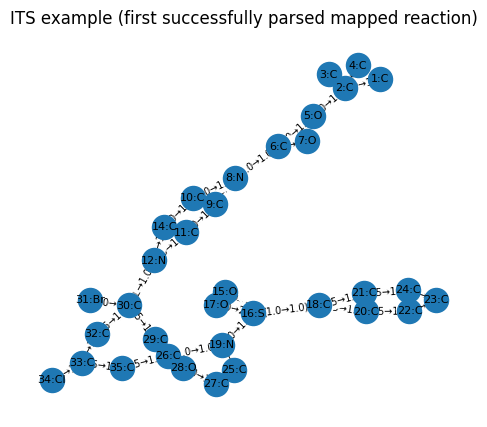

In [6]:
import matplotlib.pyplot as plt

def _fmt_order(x: BondOrder) -> str:
    return "⊥" if x is None else str(x)

def draw_its(G: nx.Graph, center_nodes: Optional[set[int]] = None, title: str = "ITS"):
    # deterministic layout
    pos = nx.spring_layout(G, seed=0)
    plt.figure(figsize=(6, 5))
    nx.draw_networkx_nodes(G, pos)
    nx.draw_networkx_edges(G, pos, alpha=0.6)

    # node labels: map id + symbol
    nlabels = {v: f"{v}:{G.nodes[v].get('symbol','?')}" for v in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=nlabels, font_size=8)

    # edge labels: r->p
    elabs = {}
    for u, v, d in G.edges(data=True):
        elabs[(u, v)] = f"({_fmt_order(d.get('r_order'))}→{_fmt_order(d.get('p_order'))})"
    nx.draw_networkx_edge_labels(G, pos, edge_labels=elabs, font_size=7)

    if center_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=list(center_nodes), node_size=450, alpha=0.25)

    plt.title(title)
    plt.axis('off')
    plt.show()

if its_graphs:
    draw_its(its_graphs[0], title="ITS example (first successfully parsed mapped reaction)")
else:
    print("No ITS graphs available (ensure mapping succeeded and ITS construction ran).")    


## 4. Extract the reaction center


### 4.1 Center definition used in this notebook

We define the *core* center atoms \(C_0\) as atoms incident to **changed bonds**:

\[
C_0 = \{v \mid \exists e \text{ incident to } v \text{ with } b_R(e)\neq b_P(e)\}.
\]

Optionally, we also include atoms with **formal charge changes** (reactant vs product),
because for some chemistries the bond pattern alone does not capture the transformation.

Finally, we optionally expand to radius \(r\) context and return the induced subgraph.


Center graphs (r=0): 1000


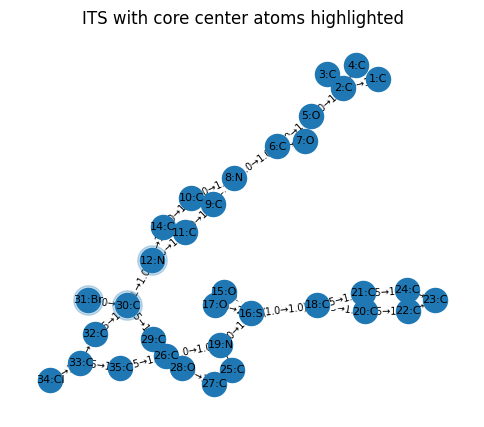

In [7]:
from collections import deque

def reaction_center_core_nodes(G: nx.Graph, include_charge_changes: bool = True) -> set[int]:
    C: set[int] = set()

    # bond changes
    for u, v, d in G.edges(data=True):
        if d.get("r_order") != d.get("p_order"):
            C.add(u)
            C.add(v)

    # optional atom-state changes
    if include_charge_changes:
        for v, nd in G.nodes(data=True):
            if nd.get("r_charge") != nd.get("p_charge"):
                # ignore Nones where one side is missing
                if nd.get("r_charge") is None or nd.get("p_charge") is None:
                    continue
                C.add(v)
    return C

def expand_radius(G: nx.Graph, seeds: set[int], radius: int) -> set[int]:
    if radius <= 0:
        return set(seeds)
    seen = set(seeds)
    q = deque([(s, 0) for s in seeds])
    while q:
        v, dist = q.popleft()
        if dist >= radius:
            continue
        for u in G.neighbors(v):
            if u not in seen:
                seen.add(u)
                q.append((u, dist + 1))
    return seen

def extract_center_graph(G: nx.Graph, radius: int = 0, include_charge_changes: bool = True) -> nx.Graph:
    core = reaction_center_core_nodes(G, include_charge_changes=include_charge_changes)
    nodes = expand_radius(G, core, radius=radius)
    H = G.subgraph(nodes).copy()
    H.graph["core_nodes"] = sorted(core)
    H.graph["radius"] = int(radius)
    return H

# Build center graphs for all ITS graphs
center_graphs_r0: List[nx.Graph] = [extract_center_graph(G, radius=0, include_charge_changes=True) for G in its_graphs]
print("Center graphs (r=0):", len(center_graphs_r0))

# Show one example center overlaid on ITS
if its_graphs:
    core0 = reaction_center_core_nodes(its_graphs[0], include_charge_changes=True)
    draw_its(its_graphs[0], center_nodes=core0, title="ITS with core center atoms highlighted")


### 4.2 Visualize the reaction center on the molecules

We highlight center atoms (by map id) on both sides of the mapped reaction.


Reactants (center atoms highlighted)


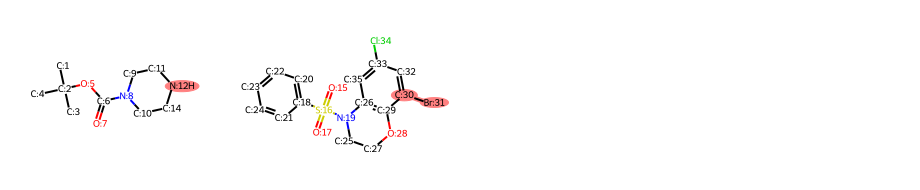

Products (center atoms highlighted)


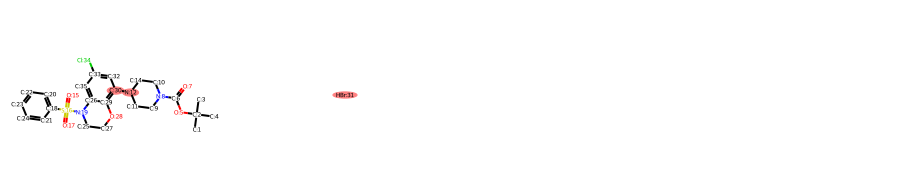

In [8]:
def highlight_center_on_mols(mapped_rxn: str, center_map_ids: set[int], max_mols_per_side: int = 4):
    r_smi, p_smi = _split_rxn_smiles(mapped_rxn)
    r_mols = [Chem.MolFromSmiles(s) for s in r_smi.split(".") if s]
    p_mols = [Chem.MolFromSmiles(s) for s in p_smi.split(".") if s]

    def prep(m: Chem.Mol):
        if m is None:
            return m
        for a in m.GetAtoms():
            amap = a.GetAtomMapNum()
            if amap:
                a.SetProp("molAtomMapNumber", str(amap))
        return m

    r_mols = [prep(m) for m in r_mols]
    p_mols = [prep(m) for m in p_mols]

    def hi_atoms(m: Chem.Mol) -> List[int]:
        out = []
        for a in m.GetAtoms():
            if int(a.GetAtomMapNum() or 0) in center_map_ids:
                out.append(a.GetIdx())
        return out

    r_hi = [hi_atoms(m) for m in r_mols if m is not None]
    p_hi = [hi_atoms(m) for m in p_mols if m is not None]

    img_r = Draw.MolsToGridImage(
        [m for m in r_mols if m is not None][:max_mols_per_side],
        molsPerRow=4,
        subImgSize=(230, 190),
        highlightAtomLists=r_hi[:max_mols_per_side],
    )
    img_p = Draw.MolsToGridImage(
        [m for m in p_mols if m is not None][:max_mols_per_side],
        molsPerRow=4,
        subImgSize=(230, 190),
        highlightAtomLists=p_hi[:max_mols_per_side],
    )
    print("Reactants (center atoms highlighted)")
    display(img_r)
    print("Products (center atoms highlighted)")
    display(img_p)

if its_graphs and its_meta:
    ex = its_meta[0]["mapped_rxn"]
    core = reaction_center_core_nodes(its_graphs[0], include_charge_changes=True)
    highlight_center_on_mols(ex, core)


## 5. Reaction center clustering via typed isomorphism


### 5.1 Typed matching predicates

We treat each center as a typed graph with:

- node labels: \((\text{symbol}, r\_charge, p\_charge)\)
- edge labels: \((r\_order, p\_order)\)

Two centers are equivalent if there exists an isomorphism preserving these labels.

> You can relax or strengthen these predicates depending on your use-case:
> - ignore charge,
> - treat aromatic \(1.5\) specially,
> - include radius-1 context, etc.


In [9]:
from networkx.algorithms import isomorphism as iso

def node_match_strict(d1: dict, d2: dict) -> bool:
    return (
        d1.get("symbol") == d2.get("symbol")
        and d1.get("r_charge") == d2.get("r_charge")
        and d1.get("p_charge") == d2.get("p_charge")
    )

def edge_match_strict(d1: dict, d2: dict) -> bool:
    return (d1.get("r_order"), d1.get("p_order")) == (d2.get("r_order"), d2.get("p_order"))

def cluster_centers_isomorphism(graphs: Sequence[nx.Graph]) -> Tuple[List[int], List[List[int]]]:
    """Return (cluster_id_per_graph, clusters_as_lists_of_indices)."""
    reps: List[int] = []         # representative index per cluster
    clusters: List[List[int]] = []
    gid: List[int] = [-1] * len(graphs)

    for i, Gi in enumerate(graphs):
        assigned = False
        for c, rep in enumerate(reps):
            G0 = graphs[rep]
            GM = iso.GraphMatcher(G0, Gi, node_match=node_match_strict, edge_match=edge_match_strict)
            if GM.is_isomorphic():
                gid[i] = c
                clusters[c].append(i)
                assigned = True
                break
        if not assigned:
            gid[i] = len(reps)
            reps.append(i)
            clusters.append([i])
    return gid, clusters

t0 = time.perf_counter()
gid_iso, clusters_iso = cluster_centers_isomorphism(center_graphs_r0)
dt = time.perf_counter() - t0

sizes = sorted([len(c) for c in clusters_iso], reverse=True)
print(f"Isomorphism clustering: {len(center_graphs_r0)} graphs -> {len(clusters_iso)} clusters | time={dt:.3f}s")
print("Top cluster sizes:", sizes[:10])

# Display a small summary table
summary = pd.DataFrame({
    "cluster_id": list(range(len(clusters_iso))),
    "size": [len(c) for c in clusters_iso],
}).sort_values("size", ascending=False)
display(summary.head(10))


Isomorphism clustering: 1000 graphs -> 101 clusters | time=0.264s
Top cluster sizes: [168, 136, 71, 59, 47, 42, 42, 41, 26, 26]


,cluster_id,size
8,8,168
2,2,136
0,0,71
5,5,59
6,6,47
14,14,42
12,12,42
3,3,41
1,1,26
13,13,26


### 5.2 Inspect representative centers

A cluster representative is the first center graph assigned to that cluster.


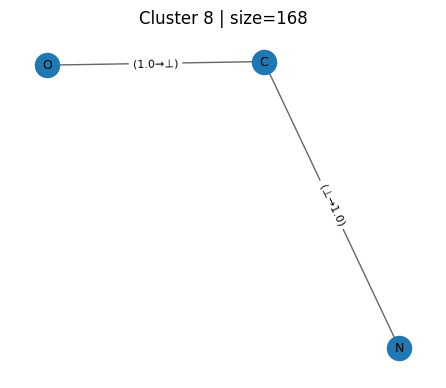

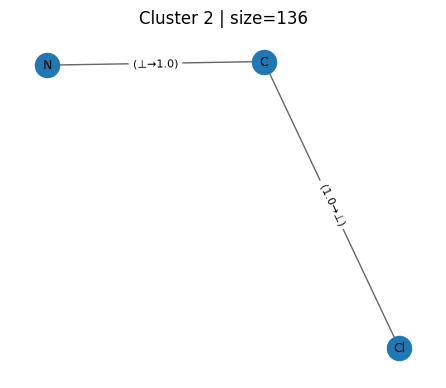

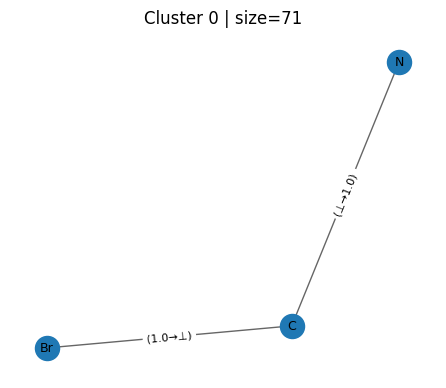

In [10]:
def draw_center(H: nx.Graph, title: str = "Center graph"):
    pos = nx.spring_layout(H, seed=0)
    plt.figure(figsize=(5.5, 4.5))
    nx.draw_networkx_nodes(H, pos)
    nx.draw_networkx_edges(H, pos, alpha=0.6)
    nlabels = {v: f"{H.nodes[v].get('symbol','?')}" for v in H.nodes()}
    nx.draw_networkx_labels(H, pos, labels=nlabels, font_size=9)

    elabs = {(u, v): f"({_fmt_order(d.get('r_order'))}→{_fmt_order(d.get('p_order'))})" for u, v, d in H.edges(data=True)}
    nx.draw_networkx_edge_labels(H, pos, edge_labels=elabs, font_size=8)

    plt.title(title)
    plt.axis('off')
    plt.show()

# Show up to 3 largest clusters
for rank, row in summary.head(3).iterrows():
    cid = int(row["cluster_id"])
    rep_idx = clusters_iso[cid][0]
    H = center_graphs_r0[rep_idx]
    draw_center(H, title=f"Cluster {cid} | size={len(clusters_iso[cid])}")    


## 6. Accelerate clustering with WL graph hashing (prefilter)


### 6.1 WL hash prefilter

We compute a WL hash for each center graph using label strings:

- node label: `symbol | r_charge → p_charge`
- edge label: `r_order → p_order` (with `⊥` for absent)

Then we group by hash and run expensive isomorphism only within each group.

> **Reminder:** WL hashing is an isomorphism-invariant heuristic, not a proof.
> We still run exact isomorphism within each hash bucket to obtain correct clusters.


In [12]:
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash

def ascii_safe(x: Any) -> str:
    """
    Convert any label to a deterministic ASCII-only string.
    """
    s = str(x)
    return (
        s.replace("⊥", "_NULL_")
         .replace("→", "->")
         .replace("←", "<-")
         .replace("Δ", "DELTA")
    )


def annotate_for_wl(G: nx.Graph) -> None:
    """
    Prepare ASCII-only WL labels for nodes and edges.
    """
    for _, d in G.nodes(data=True):
        d["wl_node"] = ascii_safe((
            d.get("symbol"),
            d.get("formal_charge"),
            d.get("aromatic"),
            d.get("center", False),
            d.get("delta", 0),
        ))

    for _, _, d in G.edges(data=True):
        d["wl_edge"] = ascii_safe((
            d.get("order"),
            d.get("aromatic"),
            d.get("change", None),
        ))


def wl_hash(G: nx.Graph, iterations: int = 2) -> str:
    annotate_for_wl(G)
    return weisfeiler_lehman_graph_hash(
        G,
        node_attr="wl_node",
        edge_attr="wl_edge",
        iterations=iterations,
    )

def cluster_centers_wl_prefilter(graphs: Sequence[nx.Graph], wl_iters: int = 2):
    # 1) bucket by WL hash
    buckets: Dict[str, List[int]] = defaultdict(list)
    hashes: List[str] = []
    for i, G in enumerate(graphs):
        h = wl_hash(G, iterations=wl_iters)
        hashes.append(h)
        buckets[h].append(i)

    # 2) within each bucket, do exact isomorphism clustering
    gid = [-1] * len(graphs)
    clusters: List[List[int]] = []

    for h, idxs in buckets.items():
        sub = [graphs[i] for i in idxs]
        sub_gid, sub_clusters = cluster_centers_isomorphism(sub)
        # map back to global indices
        for local_cid, members in enumerate(sub_clusters):
            members_global = [idxs[j] for j in members]
            cid_global = len(clusters)
            clusters.append(members_global)
            for gi in members_global:
                gid[gi] = cid_global

    return hashes, gid, clusters, buckets

t0 = time.perf_counter()
hashes, gid_wl, clusters_wl, buckets = cluster_centers_wl_prefilter(center_graphs_r0, wl_iters=2)
dt = time.perf_counter() - t0

print(f"WL-prefilter clustering: {len(center_graphs_r0)} graphs -> {len(clusters_wl)} clusters | time={dt:.3f}s")
print(f"Number of WL buckets: {len(buckets)} | mean bucket size: {sum(len(v) for v in buckets.values())/len(buckets):.2f}")


WL-prefilter clustering: 1000 graphs -> 101 clusters | time=0.089s
Number of WL buckets: 84 | mean bucket size: 11.90


### 6.2 Sanity check: WL-prefilter + exact isomorphism equals exact isomorphism alone

Because WL is only a prefilter, the final clustering should be identical to direct isomorphism clustering
(up to cluster id renaming).


In [13]:
def normalize_partition(clusters: List[List[int]]) -> List[Tuple[int, ...]]:
    return sorted([tuple(sorted(c)) for c in clusters])

part_iso = normalize_partition(clusters_iso)
part_wl = normalize_partition(clusters_wl)

print("Partitions identical:", part_iso == part_wl)


Partitions identical: True


## 7. Convert reaction centers into DPO rules


### 7.1 Practical rule extraction used here

Given an ITS graph \(G_{\mathrm{ITS}}\) and a chosen context node set \(C_r\), we build:

- \(L\): **reactant pattern** on \(C_r\) (keep only bonds with \(b_R\neq\bot\))
- \(R\): **product pattern** on \(C_r\) (keep only bonds with \(b_P\neq\bot\))
- \(K\): **preserved context** on \(C_r\) (keep only bonds with \(b_R=b_P\neq\bot\))

Nodes:
- \(L\) nodes carry `symbol` and `charge=r_charge`
- \(R\) nodes carry `symbol` and `charge=p_charge`
- \(K\) nodes carry `symbol` only (identity type)

This yields a DPO-style span \(L \leftarrow K \rightarrow R\) that is directly interpretable as:
“delete bonds in \(L\setminus K\), keep bonds in \(K\), create bonds in \(R\setminus K\)”.

> For production systems, you may also:
> - include stereochemistry / aromatic flags explicitly,
> - attach atom environments,
> - require connected centers,
> - handle reagents vs true reactants,
> - normalize charges, etc.


Rule meta:
core_nodes [12, 30, 31]
context_radius 1
context_nodes [11, 12, 14, 29, 30, 31, 32]
deleted_edges | 1
added_edges | 1
n_L 7
n_K 7
n_R 7
m_L 5
m_K 4
m_R 5


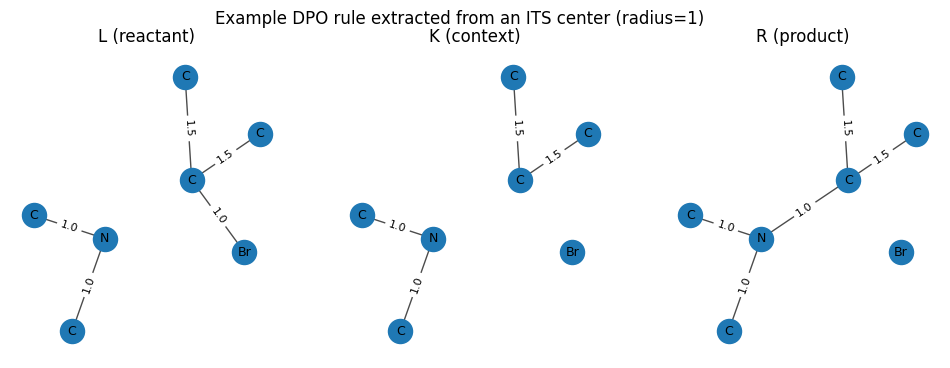

In [14]:
@dataclass(frozen=True)
class DPORule:
    L: nx.Graph
    K: nx.Graph
    R: nx.Graph
    meta: Dict[str, object]

def its_to_dpo_rule(G: nx.Graph, core_radius: int = 1, include_charge_changes: bool = True) -> DPORule:
    # choose context nodes
    core = reaction_center_core_nodes(G, include_charge_changes=include_charge_changes)
    C = expand_radius(G, core, radius=core_radius)

    # node existence
    L_nodes = [v for v in C if G.nodes[v].get("r_charge") is not None]
    R_nodes = [v for v in C if G.nodes[v].get("p_charge") is not None]
    K_nodes = [v for v in C if (G.nodes[v].get("r_charge") is not None and G.nodes[v].get("p_charge") is not None)]

    # build L, R, K
    L = nx.Graph()
    for v in sorted(L_nodes):
        L.add_node(v, symbol=G.nodes[v].get("symbol"), charge=G.nodes[v].get("r_charge"))
    R = nx.Graph()
    for v in sorted(R_nodes):
        R.add_node(v, symbol=G.nodes[v].get("symbol"), charge=G.nodes[v].get("p_charge"))
    K = nx.Graph()
    for v in sorted(K_nodes):
        K.add_node(v, symbol=G.nodes[v].get("symbol"))

    # edges
    for u, v, d in G.edges(data=True):
        if u not in C or v not in C:
            continue
        ro, po = d.get("r_order"), d.get("p_order")

        if ro is not None and (u in L and v in L):
            L.add_edge(u, v, order=ro)
        if po is not None and (u in R and v in R):
            R.add_edge(u, v, order=po)
        if (ro is not None) and (po is not None) and (ro == po) and (u in K and v in K):
            K.add_edge(u, v, order=ro)

    # meta: summarize edits
    L_edges = {(min(u,v), max(u,v), d["order"]) for u,v,d in L.edges(data=True)}
    R_edges = {(min(u,v), max(u,v), d["order"]) for u,v,d in R.edges(data=True)}
    K_edges = {(min(u,v), max(u,v), d["order"]) for u,v,d in K.edges(data=True)}

    deleted = sorted(L_edges - K_edges)
    added = sorted(R_edges - K_edges)

    meta = {
        "core_nodes": sorted(core),
        "context_radius": int(core_radius),
        "context_nodes": sorted(C),
        "deleted_edges": deleted,
        "added_edges": added,
        "n_L": L.number_of_nodes(),
        "n_K": K.number_of_nodes(),
        "n_R": R.number_of_nodes(),
        "m_L": L.number_of_edges(),
        "m_K": K.number_of_edges(),
        "m_R": R.number_of_edges(),
    }
    return DPORule(L=L, K=K, R=R, meta=meta)

def draw_dpo(rule: DPORule, title: str = "DPO rule"):
    # consistent layout: union graph
    U = nx.Graph()
    for G in (rule.L, rule.K, rule.R):
        U.add_nodes_from(G.nodes())
        U.add_edges_from([(u, v) for u, v in G.edges()])
    pos = nx.spring_layout(U, seed=0)

    def _draw(G: nx.Graph, ax, name: str):
        ax.set_title(name)
        nx.draw_networkx_nodes(G, pos, ax=ax)
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.7)
        nlabels = {v: f"{G.nodes[v].get('symbol','?')}" for v in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=nlabels, font_size=9, ax=ax)
        elabs = {(u, v): str(d.get("order")) for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=elabs, font_size=8, ax=ax)
        ax.axis('off')

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    _draw(rule.L, axes[0], "L (reactant)")
    _draw(rule.K, axes[1], "K (context)")
    _draw(rule.R, axes[2], "R (product)")
    fig.suptitle(title)
    plt.show()

# Example: build one rule and draw it
if its_graphs:
    rule0 = its_to_dpo_rule(its_graphs[0], core_radius=1, include_charge_changes=True)
    print("Rule meta:")
    for k, v in rule0.meta.items():
        if k.endswith("edges"):
            print(k, "|", len(v))
        else:
            print(k, v)
    draw_dpo(rule0, title="Example DPO rule extracted from an ITS center (radius=1)")
else:
    print("No ITS graphs available.")    


### 7.2 Extract rules for all reactions and export

We extract one DPO rule per reaction (for a chosen center radius), then optionally export:

- all rules
- cluster representatives (one per isomorphism class of centers)

The export format is a simple JSON with nodes/edges for L,K,R.


In [15]:
import json

def graph_to_json(G: nx.Graph) -> dict:
    return {
        "nodes": [{"id": int(v), **{k: G.nodes[v][k] for k in G.nodes[v]}} for v in G.nodes()],
        "edges": [
            {"u": int(u), "v": int(v), **{k: d[k] for k in d}}
            for u, v, d in G.edges(data=True)
        ],
    }

def rule_to_json(rule: DPORule) -> dict:
    return {
        "meta": rule.meta,
        "L": graph_to_json(rule.L),
        "K": graph_to_json(rule.K),
        "R": graph_to_json(rule.R),
    }

# Build all rules (skip reactions where ITS failed)
rules_all: List[DPORule] = [its_to_dpo_rule(G, core_radius=1, include_charge_changes=True) for G in its_graphs]
print("Extracted rules:", len(rules_all))

# Representative rules per isomorphism cluster (centers at r=0)
rep_rules = []
for cid, members in enumerate(clusters_iso):
    rep_idx = members[0]
    # rep_idx indexes center_graphs_r0; same index also indexes its_graphs
    rep_rules.append(rules_all[rep_idx])

print("Representative rules:", len(rep_rules))

# Write JSON to disk
out_path = Path("rules_s04_representatives.json")
with out_path.open("w", encoding="utf-8") as f:
    json.dump([rule_to_json(r) for r in rep_rules], f, indent=2)

print("Wrote:", out_path.resolve())


Extracted rules: 1000
Representative rules: 101
Wrote: /home/lolo/Documents/TACsy/SynEco/SynEdu/synedu/S04/rules_s04_representatives.json


## 8. Exercises & quiz

<div class="alert alert-block alert-info">
<b>Cross-referencing.</b> Concepts used here build on:
- <b>S01</b>: typed graphs, isomorphism, automorphisms
- <b>S03</b>: (if you have it) reaction-side graph construction and label design choices
</div>

### Exercise 1 — Center radius as a hyperparameter

Implement `radius=2` and compare:
- cluster counts,
- representative centers,
- rule sizes (nodes/edges).

**Chemistry intuition:** larger radii incorporate more “environment”, making rules more specific.

### Exercise 2 — Relax the typing

Modify the matcher to ignore charge:

- node label uses only `symbol`
- edge label still uses `(r_order, p_order)`

Does the number of clusters decrease? Which chemistries merge?

### Exercise 3 — WL iterations vs collisions

Change `wl_iters` in `cluster_centers_wl_prefilter` and measure:
- runtime,
- number of WL buckets,
- collision rate (bucket size distribution).

### Quiz (conceptual)

1. What would go wrong if we define \(K\) as empty for every rule?
2. How does a bond order change (single→double) appear in the \(L,K,R\) decomposition?
3. In practice, why is WL hashing only a prefilter and not a proof of isomorphism?
4. If RXNMapper assigns a wrong map id, which step in the pipeline is most sensitive, and why?


In [16]:
# --- Exercise 1: radius comparison (starter) ---
#
# Try: radius in {0,1,2} and compare number of clusters.

def centers_for_radius(radius: int) -> List[nx.Graph]:
    return [extract_center_graph(G, radius=radius, include_charge_changes=True) for G in its_graphs]

for r in [0, 1, 2]:
    gs = centers_for_radius(r)
    t0 = time.perf_counter()
    _, clusters_r = cluster_centers_isomorphism(gs)
    dt = time.perf_counter() - t0
    print(f"radius={r} | clusters={len(clusters_r)} | time={dt:.3f}s")

# --- Exercise 2: relax typing (ignore charge) ---
def node_match_symbol_only(d1: dict, d2: dict) -> bool:
    return d1.get("symbol") == d2.get("symbol")

def cluster_centers_symbol_only(graphs: Sequence[nx.Graph]) -> Tuple[List[int], List[List[int]]]:
    reps: List[int] = []
    clusters: List[List[int]] = []
    gid: List[int] = [-1] * len(graphs)
    for i, Gi in enumerate(graphs):
        assigned = False
        for c, rep in enumerate(reps):
            G0 = graphs[rep]
            GM = iso.GraphMatcher(G0, Gi, node_match=node_match_symbol_only, edge_match=edge_match_strict)
            if GM.is_isomorphic():
                gid[i] = c
                clusters[c].append(i)
                assigned = True
                break
        if not assigned:
            gid[i] = len(reps)
            reps.append(i)
            clusters.append([i])
    return gid, clusters

t0 = time.perf_counter()
_, clusters_relaxed = cluster_centers_symbol_only(center_graphs_r0)
dt = time.perf_counter() - t0
print(f"Relaxed (symbol-only) clustering: clusters={len(clusters_relaxed)} | time={dt:.3f}s")

# --- Exercise 3: WL collision diagnostics ---
def bucket_size_stats(buckets: Dict[str, List[int]]) -> pd.DataFrame:
    sizes = [len(v) for v in buckets.values()]
    return pd.DataFrame({"bucket_size": sizes}).describe()

for iters in [1, 2, 3]:
    _, _, _, b = cluster_centers_wl_prefilter(center_graphs_r0, wl_iters=iters)
    stats = bucket_size_stats(b)
    print(f"WL iters={iters} | buckets={len(b)}")
    display(stats)


radius=0 | clusters=101 | time=0.227s
radius=1 | clusters=287 | time=0.776s
radius=2 | clusters=731 | time=1.912s
Relaxed (symbol-only) clustering: clusters=98 | time=0.231s
WL iters=1 | buckets=84


,bucket_size
count,84.000000
mean,11.904762
std,30.529709
min,1.000000
25%,1.000000
50%,3.000000
75%,8.000000
max,228.000000


WL iters=2 | buckets=84


,bucket_size
count,84.000000
mean,11.904762
std,30.529709
min,1.000000
25%,1.000000
50%,3.000000
75%,8.000000
max,228.000000


WL iters=3 | buckets=84


,bucket_size
count,84.000000
mean,11.904762
std,30.529709
min,1.000000
25%,1.000000
50%,3.000000
75%,8.000000
max,228.000000


# References and further reading

- RXNMapper: Schwaller et al., transformer-based atom mapping (see the RXNMapper repository / publication).
- ITS graphs in reaction modeling: classic “imaginary transition state” representations in reaction informatics.
- Double pushout (DPO) graph rewriting: Ehrig et al., algebraic graph transformation (intro texts); chemical applications in rule-based reaction systems.
- Weisfeiler–Lehman (WL) refinement and hashing: WL test / color refinement; widely used in cheminformatics fingerprints and GNN theory.
- RDKit documentation and book: https://www.rdkit.org/docs/
- NetworkX documentation: https://networkx.org/documentation/stable/

> For a publication-quality method section, replace these bullets with full BibTeX entries and pin exact tool versions.
